In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as opt
import os

# Data Ingest

From the raw .Spe file collect:
* The recording time
* The real time
* The live time
* The spectrum of data 

In [2]:
# path = r"C:\pyt\ADV-Lab\nuetron-activation\Data\Old_setup"
# TOTAL_CHANNELS = 1024

path = r"C:\pyt\ADV-Lab\nuetron-activation\Data\New_setup"
TOTAL_CHANNELS = 16383

# The lines of interest in the .Spe data file (starting from 0)
start_time_line = 7
measurement_time_line = 9
data_start_line = 12
data_end_line = 12 + TOTAL_CHANNELS

In [3]:
def get_data(path):
    in_file = open(path, "r")

    lines = in_file.readlines()

    start = lines[start_time_line].strip().split(" ")
    start_date, start_time = start[0], start[1]

    measurement_time = lines[measurement_time_line].strip().split(" ")
    live_time, real_time  = measurement_time[0], measurement_time[1]

    data = lines[data_start_line:data_end_line]

    data_dict = {
        "start_date": start_date,
        "start_time": start_time,
        "live_time": float(live_time),
        "real_time": float(real_time),
        "dead_time": float(np.divide(np.subtract(float(real_time),float(live_time)),float(real_time)) * 100),
        "data": [int(x.strip()) for x in data]
    }

    in_file.close()

    return data_dict


In [4]:
background_dict = get_data(r"C:\pyt\ADV-Lab\nuetron-activation\Data\New_setup\9_15_26_Background.Spe")
sample_dict = get_data(r"C:\pyt\ADV-Lab\nuetron-activation\Data\New_setup\9_15_26Na_sample.Spe")
sample_dict

{'start_date': '09/15/2026',
 'start_time': '14:14:21',
 'live_time': 774.88,
 'real_time': 796.0,
 'dead_time': 2.6532663316582923,
 'data': [0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  6,
  131,
  649,
  671,
  191,
  71,
  54,
  50,
  63,
  59,
  67,
  76,
  80,
  91,
  78,
  82,
  94,
  91,
  101,
  96,
  105,
  109,
  104,
  113,
  129,
  117,
  109,
  92,
  102,
  114,
  96,
  99,
  85,
  81,
  121,
  100,
  88,
  87,
  90,
  95,
  84,
  85,
  82,
  94,
  83,
  94,
  85,
  91,
  100,
  106,
  117,
  99,
  94,
  107,
  113,
  115,
  110,
  94,
  106,
  103,
  118,
  113,
  96,
  104,
  80,
  107,
  107,
  115,
  109,
  118,
  120,
  115,
  95,
  107,
  96,
  99,
  97,
  96,
  120,
  116,
  112,
  113,
  116,
  116,
  112,
  114,
  110,
  120,
  125,
  95,
  124,
  101,
  125,
  

# Spectrum Plot

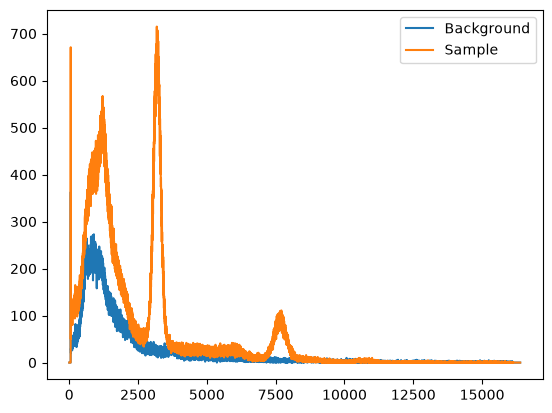

In [5]:
background_data = background_dict["data"]
sample_data = sample_dict["data"]
channels = np.arange(1, TOTAL_CHANNELS + 1)

plt.plot(channels, background_data, label="Background")
plt.plot(channels, sample_data, label="Sample")
plt.legend()

# Subtracting Background

In [6]:
def sub_background_linear(sample_dict, background_dict):
    """assumes the background grows at a linear rate"""

    # multiply the background spectrum by the ratio of the sample and background live times
    sample_live_time = float(sample_dict["live_time"])
    background_live_time = float(background_dict["live_time"])

    ratio = sample_live_time / background_live_time

    background_data = np.array(background_dict["data"])
    scaled_background = background_data * ratio

    # subtract the scaled background from the sample data
    sample_data = np.array(sample_dict["data"])

    subtracted_data = sample_data - scaled_background

    return subtracted_data


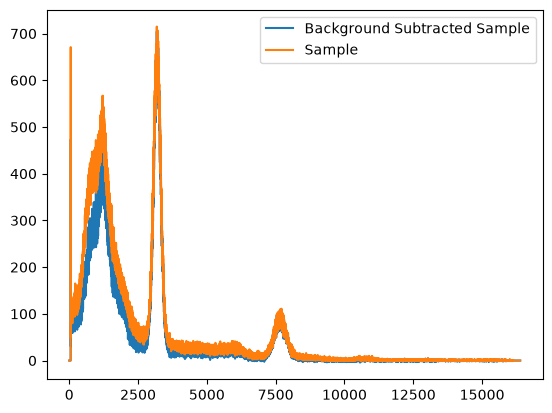

In [7]:
background_subtracted_data = sub_background_linear(sample_dict, background_dict)

plt.plot(channels, background_subtracted_data, label="Background Subtracted Sample")
plt.plot(channels, sample_dict["data"], label="Sample")
plt.legend()


# Fitting gaussian

In [8]:
def gaussian(x, A, x0, sigma):
    """Gaussian function"""
    return A * np.exp(-(x - x0) ** 2 / (2 * sigma ** 2))

def fit_gaussian(data, start_channel, end_channel):
    """Fit a Gaussian to the data between start_channel and end_channel"""

    # Get the data in the range
    x_data = np.arange(start_channel, end_channel + 1)
    y_data = data[start_channel - 1:end_channel]

    # Initial guess for the parameters
    initial_guess = [max(y_data), (start_channel + end_channel) / 2, (end_channel - start_channel) / 4]

    # Fit the Gaussian
    popt, pcov = opt.curve_fit(gaussian, x_data, y_data, p0=initial_guess)

    fit_A, fit_x0, fit_sigma = popt

    fit_y_data = gaussian(np.arange(start_channel, end_channel), fit_A, fit_x0, fit_sigma)

    return fit_y_data, fit_x0, fit_sigma, fit_A

def fit_energy_gaussian(peak_data, x_data):
    """Fit a Gaussian to the peak in energy"""

    start_energy = x_data[0]
    end_energy  = x_data[-1]

    # Initial guess for the parameters
    initial_guess = [max(peak_data), (start_energy  + end_energy ) / 2, (end_energy  - start_energy ) / 4]

    # Fit the Gaussian
    popt, pcov = opt.curve_fit(gaussian, x_data, peak_data, p0=initial_guess)

    fit_A, fit_x0, fit_sigma = popt

    fit_y_data = gaussian(x_data, fit_A, fit_x0, fit_sigma)

    return fit_y_data, fit_x0, fit_sigma, fit_A

In [19]:
def get_counts(fit_sigma, fit_A):
    """ Fit a gaussian to the peak and integrate the curve"""

    # a = 1 / (2 * fit_sigma ** 2)
    # counts = fit_A * np.sqrt(np.pi / a)

    counts = fit_A * fit_sigma * np.sqrt(2*np.pi)

    # 99.99% is +- 4 sigma
    # range_of_peak_high = fit_x0 + (4*fit_sigma)
    # range_of_peak_low = fit_x0 - (4*fit_sigma) 
    # full_range = np.arange(int(range_of_peak_low), int(range_of_peak_high) + 1)

    # # sum counts in full range
    # counts = np.sum(data[full_range])

    return counts 

139.99508308172693
219480.99946660924


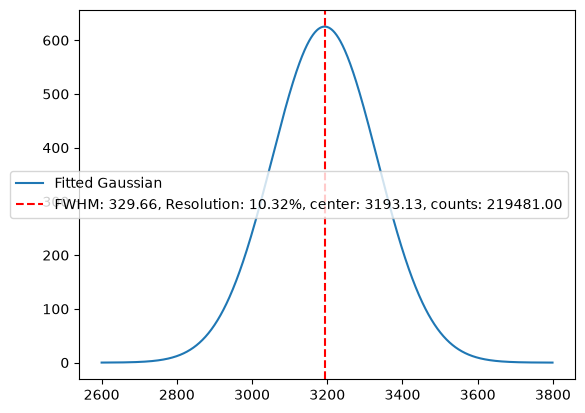

In [10]:
peak_channels = [2600, 3800]
# peak_channels = [6800, 8600]  # Replace with the actual peak channels you want to fit

fit_y_data, fit_x0, fit_sigma, fit_A = fit_gaussian(background_subtracted_data, peak_channels[0], peak_channels[1])
print(fit_sigma)

counts = get_counts(fit_sigma, fit_A)
print(counts)

plt.plot(np.arange(peak_channels[0], peak_channels[1]), fit_y_data, label="Fitted Gaussian")

fwhm = 2 * np.sqrt(2 * np.log(2)) * fit_sigma 
res = fwhm / fit_x0 * 100
plt.axvline(fit_x0, color='red', linestyle='--', label=f'FWHM: {fwhm:.2f}, Resolution: {res:.2f}%, center: {fit_x0:.2f}, counts: {counts:.2f}')
plt.legend()


# Calibration

In [11]:
def get_calibration(peak_1, peak_2, peak_3 = None):
    """
    given a dictionary with the data, peak channel numbers, and the energy for each peak. Get the calibration parameters.

    """

    # Extract the data, peak channels, and energies
    data_1 = peak_1['data']
    peak_channels_1 = peak_1['peak_channels']
    fit_y_data_1, fit_x0_1, fit_sigma_1, fit_A_1 = fit_gaussian(data_1, peak_channels_1[0], peak_channels_1[1])
    energy_1 = peak_1['energy']

    data_2 = peak_2['data']
    peak_channels_2 = peak_2['peak_channels']
    fit_y_data_2, fit_x0_2, fit_sigma_2, fit_A_2 = fit_gaussian(data_2, peak_channels_2[0], peak_channels_2[1])
    energy_2 = peak_2['energy']

    if peak_3 is not None:
        data_3 = peak_3['data']
        peak_channels_3 = peak_3['peak_channels']
        fit_y_data_3, fit_x0_3, fit_sigma_3, fit_A_3 = fit_gaussian(data_3, peak_channels_3[0], peak_channels_3[1])
        energy_3 = peak_3['energy']

        # Calculate the calibration parameters
        # fit a quadratic function to the three peaks
        x = np.array([fit_x0_1, fit_x0_2, fit_x0_3])
        y = np.array([energy_1, energy_2, energy_3])

        # Perform a quadratic fit
        coeffs = np.polyfit(x, y, 2)
        m = coeffs[0]
        b = coeffs[1]
        c = coeffs[2]

        return m, b, c

    else:
        # Calculate the calibration parameters
        # fit a linear function to the two peaks
        x = np.array([fit_x0_1, fit_x0_2])
        y = np.array([energy_1, energy_2])

        # Perform a linear fit
        coeffs = np.polyfit(x, y, 1)
        m = coeffs[0]
        b = coeffs[1]
        c = 0

        return m, b, c

In [12]:
def get_energy_from_channel_linear(channel, m, b):
    """
    given a channel number and the calibration parameters, return the energy
    """
    energy = m * channel + b
    return energy


def get_energy_from_channel_quadratic(channel, m, b, c):
    """
    given a channel number and the calibration parameters, return the energy
    """
    energy = m * channel ** 2 + b * channel + c
    return energy

In [13]:
# cs_path = r"C:\pyt\ADV-Lab\nuetron-activation\Data\Old_setup\Cs137Cal.Spe"
# cs_dict = get_data(cs_path)
# peak_1_channels = [190, 230]

# na_path = r"C:\pyt\ADV-Lab\nuetron-activation\Data\Old_setup\Na22Cal.Spe"
# na_dict = get_data(na_path)
# peak_2_channels = [175, 210]

background_path = r"C:\pyt\ADV-Lab\nuetron-activation\Data\New_setup\9_15_26_Background.Spe"
background_dict = get_data(background_path)

na_path = r"C:\pyt\ADV-Lab\nuetron-activation\Data\New_setup\9_15_26Na_sample.Spe"
na_dict = get_data(na_path)
peak_2_channels = [2700, 3700]
peak_3_channels = [6900, 8500]



m, b, c = get_calibration(
    #{'data': cs_dict['data'], 'peak_channels': peak_1_channels, 'energy': 662},
    {'data': na_dict['data'], 'peak_channels': peak_2_channels, 'energy': 511},
    {'data': na_dict['data'], 'peak_channels': peak_3_channels, 'energy': 1274}
)

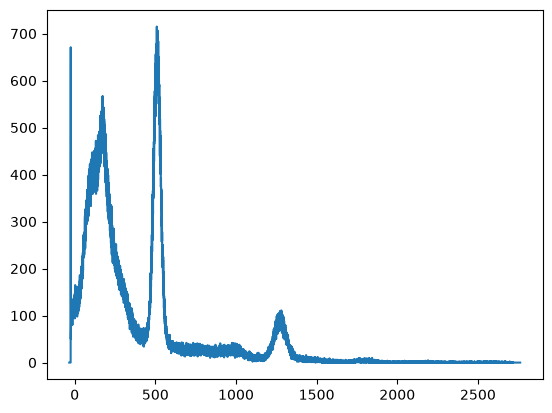

In [14]:
channels = np.arange(1, TOTAL_CHANNELS + 1)

# cs_137_data = cs_dict['data']
# cs_137_energies = [get_energy_from_channel_linear(channel, m, b) for channel in channels]

na_22_data = na_dict['data']
na_22_energies = [get_energy_from_channel_linear(channel, m, b) for channel in channels]

# plot the Cs-137 data with the calibrated energies
# plt.plot(cs_137_energies, cs_137_data)
plt.plot(na_22_energies, na_22_data)

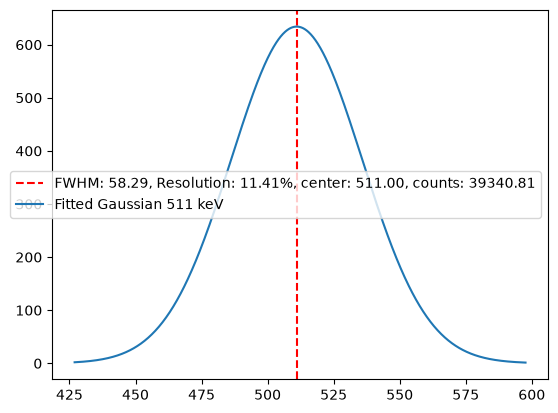

In [20]:
# gaussian fit to the Na-22 peaks

x_data_2 = na_22_energies[peak_2_channels[0]-1:peak_2_channels[1]]
peak_2_data = na_22_data[peak_2_channels[0]-1:peak_2_channels[1]]

fit_y_data, fit_x0, fit_sigma, fit_A = fit_energy_gaussian(peak_2_data, x_data_2)
fwhm_1 = 2 * np.sqrt(2 * np.log(2)) * fit_sigma
res_1 = fwhm_1 / fit_x0 * 100
counts_1 = get_counts(fit_sigma, fit_A)

plt.axvline(fit_x0, color='red', linestyle='--', label=f'FWHM: {fwhm_1:.2f}, Resolution: {res_1:.2f}%, center: {fit_x0:.2f}, counts: {counts_1:.2f}')
plt.plot(x_data_2, fit_y_data, label="Fitted Gaussian 511 keV")
plt.legend()





x_data_3 = na_22_energies[peak_3_channels[0]-1:peak_3_channels[1]]
peak_3_data = na_22_data[peak_3_channels[0]-1:peak_3_channels[1]]

fit_y_data_2, fit_x0_2, fit_sigma_2, fit_A_2 = fit_energy_gaussian(peak_3_data, x_data_3)
fwhm_2 = 2 * np.sqrt(2 * np.log(2)) * fit_sigma_2
res_2 = fwhm_2 / fit_x0_2 * 100
counts_2 = get_counts(fit_sigma_2, fit_A_2)

# plt.axvline(fit_x0_2, color='green', linestyle='--', label=f'FWHM: {fwhm_2:.2f}, Resolution: {res_2:.2f}%, center: {fit_x0_2:.2f}, counts: {counts_2:.2f}')
# plt.plot(x_data_3, fit_y_data_2, label="Fitted Gaussian 1274 keV")
# plt.legend()


# Ingesting Folder

* For each .spe file in the folder, write:
    * A png of the spectrum
    * A csv with all components of the data dict

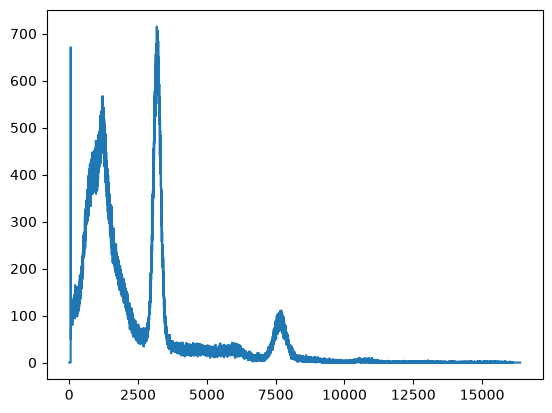

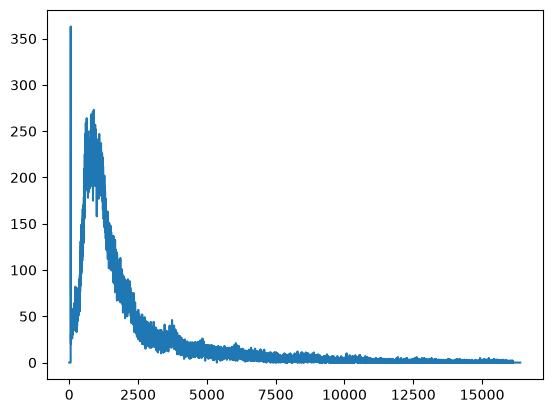

In [11]:
FOLDER_PATH = path
OUTPUT_FOLDER_PATH = FOLDER_PATH + r"\Data_ingested"

if not os.path.exists(OUTPUT_FOLDER_PATH):
    os.makedirs(OUTPUT_FOLDER_PATH)

for file in os.listdir(FOLDER_PATH):
    
    if file.endswith(".Spe"):
        file_path = os.path.join(FOLDER_PATH, file)
        data_dict = get_data(file_path)

        df = pd.DataFrame(
            {
            "start_date": [data_dict["start_date"]] * TOTAL_CHANNELS,
            "start_time": [data_dict["start_time"]] * TOTAL_CHANNELS,
            "live_time": [data_dict["live_time"]] * TOTAL_CHANNELS,
            "real_time": [data_dict["real_time"]] * TOTAL_CHANNELS,
            "dead_time": [data_dict["dead_time"]] * TOTAL_CHANNELS,
            "channel": np.arange(1, TOTAL_CHANNELS + 1),
            "counts": data_dict["data"]
             }
        )

        output_csv_path = os.path.join(OUTPUT_FOLDER_PATH, file.replace(".Spe", ".csv"))
        df.to_csv(output_csv_path, index=False)

        # create plot of the data
        plt.figure()
        plt.plot(df["channel"], df["counts"])
        plt.savefig(os.path.join(OUTPUT_FOLDER_PATH, file.replace(".Spe", ".png")))

In [12]:
def get_conc(sample, standard, background_dict, calibration):
    """ 
    Return the concentration by mass given:
        sample (required) = [ sample_dict (dictionary), weight (float, grams), channels with peak (list of 2) ]
        standard (required) = [ standard_dict (dictionary), weight (float, grams), channels with peak (list of 2), standard_concentration (float)]
        background_dict (optional)
        calibration (optional) = a function that turns a channel number into an energy KeV
    """

    # upack
    sample_dict, sample_weight, sample_channels = tuple(sample)
    sample_data = sample_dict['data']
    sample_live_time = sample_dict['live_time']

    standard_dict, standard_weight, standard_channels, standard_conc = tuple(standard)
    standard_data = standard_dict['data']
    standard_live_time = standard_dict['live_time']

    # subtract background
    if background_dict is not None:
        sample_data = sub_background_linear(sample_dict, background_dict)
        standard_data = sub_background_linear(standard_dict, background_dict)

    # get counts under the fitted gaussian to the peak
    standard_activity = get_counts(standard_data, standard_channels) / standard_live_time
    sample_activity = get_counts(sample_data, sample_channels) / sample_live_time

    sample_conc = standard_conc * (standard_weight / sample_weight) * (sample_activity / standard_activity)

    return sample_conc
